<a href="https://colab.research.google.com/github/2Low5/AVA-AI-Voice-Agent-for-Asterisk/blob/main/FIX_Fine_tuned_Vintern_1B_v3_5_for_Vietnamese_Receipt_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fine-tuning Vintern-1B-v3_5 on 5CD/Viet-Receipt-VQA**

In this notebook, we will fine-tune Vintern-1B by 5CD/Viet-Receipt-VQA an Vietnamese dataset, a new vision language model capable of various tasks, on document question answering for Vietnamese.

Reference: https://internvl.readthedocs.io/en/latest/internvl2.0/finetune.html

Check it more about us: [Fifth Civil Defender - 5CD - AI](https://huggingface.co/5CD-AI)

Let's start by installing the dependencies and loading the dataset.

In [ ]:
!pip install -q timm einops peft wandb deepspeed accelerate bitsandbytes decord tensorboardX gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━

In [ ]:
!pip install -U datasets
!pip install transformers==4.47.0
!pip install flash_attn==2.7.2.post1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.5

In [ ]:
!git clone https://github.com/5CD-AI/Vintern.git
%cd Vintern

Cloning into 'Vintern'...
remote: Enumerating objects: 2361, done.
remote: Counting objects: 100% (835/835), done.
remote: Compressing objects: 100% (213/213), done.
remote: Total 2361 (delta 672), reused 622 (delta 622), pack-reused 1526 (from 1)
Receiving objects: 100% (2361/2361), 36.42 MiB | 13.41 MiB/s, done.
Resolving deltas: 100% (1389/1389), done.
/content/Vintern


# **Load dataset**

In [ ]:
from datasets import load_dataset, Image
vi_receipt_dataset = load_dataset("5CD-AI/Viet-Receipt-VQA")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/154M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/154M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2034 [00:00<?, ? examples/s]

In [ ]:
vi_receipt_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'description', 'extractions', 'conversations'],
        num_rows: 2034
    })
})

In [ ]:
vi_receipt_dataset['train'][0]

{'id': 443,
 'image': <PIL.Image.Image image mode=RGB size=768x1024>,
 'description': 'Hóa đơn bán hàng của Vincommerce, ngày 14/08/2020, 21:37, mã hóa đơn H:00073344, NVBH:09021213,  gồm 1 mặt hàng là Kem hướng sữa  riêng Vinamilk hộp 450ml với đơn giá 43.800, tổng tiền phải trả 43.800, tiền khách trả 50.000, tiền trả lại 6.200.',
 'extractions': "{'Tên cửa hàng': 'Vincommerce', 'Địa chỉ': 'DA khu DCLB cóc 8, P. Cẩm Sơn, TP. Cẩm Phả, T. Quảng Ninh', 'Số điện thoại': '024.71066866-44561', 'Ngày bán': '14/08/2020', 'Giờ bán': '21:37', 'Số quầy': '001', 'Mã hóa đơn': 'H:00073344', 'NVBH': '09021213', 'Mặt hàng': 'Kem hướng sữa  riêng Vinamilk hộp 450ml', 'Đơn giá': '43.800', 'Số lượng': '1', 'Tổng tiền': '43.800', 'Tổng tiền à giảm': '0', 'Tiền khách trả': '43.800', 'Tiền mặt': '50.000', 'Tiền trả lại': '6.200'}",
 'conversations': [{'role': 'user',
   'content': 'Hóa đơn được xuất tại cửa hàng nào?'},
  {'role': 'assistant',
   'content': 'Hóa đơn được xuất tại cửa hàng Vincommerce.'},


# **Prepare model**

## Download model

Before starting the second fine-tuning, download the pre-trained model is provided.

In [ ]:
!mkdir -p pretrained
%cd pretrained/
# Download 5CD-AI/Vintern-1B-v2 ---- Vision Part:InternViT‑300M‑448px + Language Part: Qwen2‑0.5B‑Instruct
# !huggingface-cli download --resume-download --local-dir-use-symlinks False 5CD-AI/Vintern-1B-v2 --local-dir Vintern-1B-v2
!huggingface-cli download --resume-download --local-dir-use-symlinks False 5CD-AI/Vintern-1B-v3_5 --local-dir Vintern-1B-v3_5

/content/Vintern/pretrained
/usr/local/lib/python3.11/dist-packages/huggingface_hub/commands/download.py:139: FutureWarning: Ignoring --local-dir-use-symlinks. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Fetching 15 files:   0% 0/15 [00:00<?, ?it/s]Downloading 'config.json' to 'Vintern-1B-v3_5/.cache/huggingface/download/8_PA_wEVGiVa2goH2H4KQOQpvVY=.2668519f652eddcc2abbb56a52518d38c4f88887.incomplete'

config.json: 5.30kB [00:00, 17.4MB/s]
Download complete. Moving file to Vintern-1B-v3_5/config.json

.gitattributes: 1.52kB [00:00, 4.93MB/s]
Download complete. Moving file to Vintern-1B-v3_5/.gitattributes
Fetching 15 files:   7% 1/15 [00:00<00:10,  1.40it/s]
README.md: 10

## Test single image

Let's do inference with our dataset first to see how the model performs already with our dataset before fine-tuning. After testing you should clear the gpu (restart session) for next steps.

In [ ]:
#### Do not use flash attention if your device not support

# import json
# with open('pretrained/InternVL2-1B/config.json', 'r') as f:
#     config = json.load(f)
# config["vision_config"]["use_flash_attn"] = False
# with open('pretrained/InternVL2-1B/config.json', 'w') as f:
#     json.dump(config, f)

In [ ]:
import os
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    #check image_file is a path or image
    if isinstance(image_file, str):
        image = Image.open(image_file).convert('RGB')
    else:
        image = image_file
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
## load pretrained model
model_name = "/content/Vintern/pretrained/Vintern-1B-v3_5"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False)
model = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    use_flash_attn=False,
).eval().cuda()

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_internvl_chat.py: 0.00B [00:00, ?B/s]

conversation.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- modeling_internvl_chat.py
- conversation.py
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


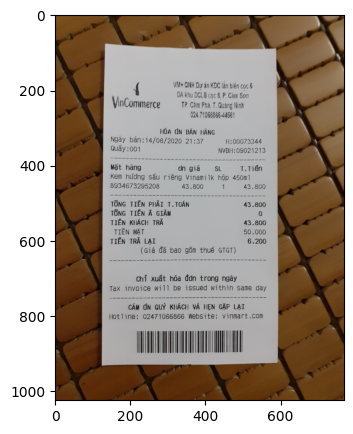

Token indices sequence length is longer than the specified maximum sequence length for this model (3400 > 1700). Running this sequence through the model will result in indexing errors
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: **Thông tin hoá đơn:**

* **Ngày bán:** 14/08/2020
* **Giờ bán:** 21:37
* **Số hoá đơn:** H:00073344
* **Số NVBH:** 09021213
* **Mặt hàng:** Kem hương sầu riêng Vinamilk hộp 450ml
* **Đơn giá:** 43.800 VNĐ
* **Số lượng:** 1
* **Tổng tiền:** 43.800 VNĐ
* **Tiền khách trả:** 43.800 VNĐ
* **Tiền giảm:** 0 VNĐ
* **Tiền trả lại:** 6.200 VNĐ


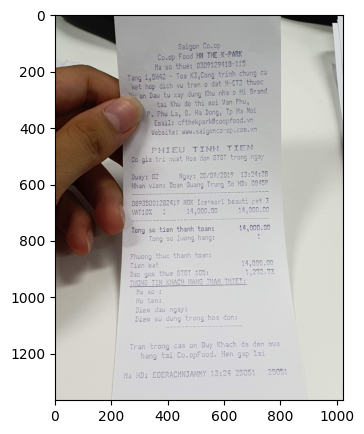

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: Hóa đơn số 0309129418-115, ngày 20/09/2019, nhân viên Đoàn Quang Trung, số hóa đơn 08459, giá trị 14.000.000 VNĐ, tổng số lượng hàng 1, VAT 10% 14.000.000 VNĐ, tiền mặt 14.000.000 VNĐ, bảo hiểm thuế GTGT 10% 14.000.000 VNĐ, thông tin khách hàng than thiết: EDERACMNJANMY 13:24 25051 25051.


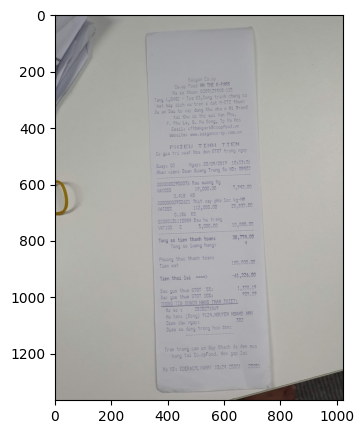

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: **Thông tin hoá đơn:**

* **Ngày:** 20/09/2019
* **Giờ:** 10:23:36
* **Quầy:** 02
* **Nhân viên:** Đoàn Quang Trung
* **Số hóa đơn:** 08422
* **Mã số thuế:** 0309129410-115
* **Công ty:** Saigon Co.op Food HN THE K-PARK
* **Địa chỉ:** Tầng 1, SH42 - Toà K3, Công trình chung cư kết hợp dịch vụ trên ô đất H-CT2 thuộc Khu nhà ở Hi Brand tại Khu đô thị mới Văn Phủ, P. Phú La, Q. Hà Đông, Tp Hà Nội.
* **Email:** cfthekpark@coopfood.vn
* **Website:** www.saigonco-op.com.vn
* **Tổng số tiền thanh toán:** 38,774.00 VNĐ
* **Tổng số lượng hàng:** 4
* **Phương thức thanh toán:** Tiền mặt
* **Tiền thừa:** -61,226.00 VNĐ
* **Thuế GTGT 5%:** 1,370.19 VNĐ
* **Thuế GTGT 10%:** 909.09 VNĐ
* **Mã hóa đơn:** E0ERACMLYANMY 10:24 25051


In [ ]:
### Test samples
for i in range(3):
    image = vi_receipt_dataset['train'][i]['image']

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.show()

    pixel_values = load_image(image, max_num=12).to(torch.bfloat16).cuda()
    generation_config = dict(max_new_tokens= 1024, do_sample=False, num_beams = 3, repetition_penalty=2.0)

    question = '<image>\nTrích xuất thông tin hoá đơn trong ảnh.'

    response = model.chat(tokenizer, pixel_values, question, generation_config)
    print(f'User: {question}\nAssistant: {response}')
    print("="*30)

In [ ]:
torch.cuda.empty_cache()

# **Prepare Your Customized Training Data**

In [ ]:
%cd /content/Vintern

/content/Vintern


## Single-Image Data
First you need to create a dataset json file to describe each item of your dataset

For single-image data, we use a **JSONL** file to store the data. Each entry is a dictionary organized in the following format. Note that each entry for single-image data must contain an image field, which is a string.

The path in the image field is relative to the root field. Concatenating the root field and the image field gives the complete path to the image. It is recommended to include width and height information for each data sample for future use.
```
{
  "id": 0,
  "image": "path/to/image.jpg",
  "width": 111,
  "height": 222,
  "conversations": [
    {"from": "human", "value": "<image>\nuser input"},
    {"from": "gpt", "value": "assistant output"},
    {"from": "human", "value": "user input"},
    {"from": "gpt", "value": "assistant output"}
  ]
}
```

Save image to image folder to get image_path to follow format of dataset

In [ ]:
import os
from tqdm import tqdm
FOLDER_IMAGES = "/content/Viet-Receipt-VQA-images"
os.makedirs(FOLDER_IMAGES, exist_ok=True)

In [ ]:

### Save image dataset
for i in tqdm(range(len(vi_receipt_dataset['train']))):
    image = vi_receipt_dataset['train'][i]['image']
    id = vi_receipt_dataset['train'][i]['id']

    #resize 448x448
    image = image.resize((448, 448)) # Just for saving vram
    image.save(f"{FOLDER_IMAGES}/{id}.jpg")

100%|██████████| 2034/2034 [00:54<00:00, 37.53it/s]


Format each item data follow format above

In [ ]:
import json

all_data = []

for item in tqdm(vi_receipt_dataset['train']):
    # Just 500 items for example
    if len(all_data) >= 50:
        break
    id = item['id']
    image = f"{FOLDER_IMAGES}/{item['id']}.jpg"
    width = item['image'].width
    height = item['image'].height
    conversations = [
            {"from": "human", "value": '<image>\nTrích xuất thông tin hoá đơn trong ảnh.'},
            {"from": "gpt", "value": str(item["extractions"])}
        ]
    data = {
        "id": id,
        "image": image,
        "width": width,
        "height": height,
        "conversations": conversations
    }
    all_data.append(data)

print(len(all_data))
print(all_data[0:5])

  2%|▏         | 50/2034 [00:00<00:11, 170.02it/s]

50
[{'id': 443, 'image': '/content/Viet-Receipt-VQA-images/443.jpg', 'width': 768, 'height': 1024, 'conversations': [{'from': 'human', 'value': '<image>\nTrích xuất thông tin hoá đơn trong ảnh.'}, {'from': 'gpt', 'value': "{'Tên cửa hàng': 'Vincommerce', 'Địa chỉ': 'DA khu DCLB cóc 8, P. Cẩm Sơn, TP. Cẩm Phả, T. Quảng Ninh', 'Số điện thoại': '024.71066866-44561', 'Ngày bán': '14/08/2020', 'Giờ bán': '21:37', 'Số quầy': '001', 'Mã hóa đơn': 'H:00073344', 'NVBH': '09021213', 'Mặt hàng': 'Kem hướng sữa  riêng Vinamilk hộp 450ml', 'Đơn giá': '43.800', 'Số lượng': '1', 'Tổng tiền': '43.800', 'Tổng tiền à giảm': '0', 'Tiền khách trả': '43.800', 'Tiền mặt': '50.000', 'Tiền trả lại': '6.200'}"}]}, {'id': 7, 'image': '/content/Viet-Receipt-VQA-images/7.jpg', 'width': 1024, 'height': 1366, 'conversations': [{'from': 'human', 'value': '<image>\nTrích xuất thông tin hoá đơn trong ảnh.'}, {'from': 'gpt', 'value': "{'Tên cửa hàng': 'Saigon Co.op', 'Chi nhánh': 'Co.op Food HN THE K-PARK', 'Mã số thuế

In [ ]:
### Write JSONL line
with open('/content/Vintern/internvl_chat/shell/data/viet-receipt-vqa.jsonl', 'w', encoding='utf-8') as f:
    for data in tqdm(all_data):
        f.write(json.dumps(data, ensure_ascii=False) + '\n')

100%|██████████| 50/50 [00:00<00:00, 37936.90it/s]


## Create meta file to manage the meta information of all datasets

After downloading the pre-trained model, prepare your customized SFT (Supervised Fine-Tuning) data. Create a JSON file in `internvl_chat/shell/data/` similar to [this example](https://github.com/OpenGVLab/InternVL/blob/main/internvl_chat/shell/data/internvl_1_2_finetune.json)

The format for the JSON file should be:

```
{
  "your-custom-dataset-1": {
    "root": "path/to/the/image/",
    "annotation": "path/to/the/jsonl/annotation",
    "data_augment": false,
    "repeat_time": 1,
    "length": "number of your data"
  },
  ...
}```



In [ ]:
metadata_datasets = {
  "vi-receipt-vqa": {
    "root": "/content/Viet-Receipt-VQA-images",
    "annotation": "/content/Vintern/internvl_chat/shell/data/viet-receipt-vqa.jsonl",
    "data_augment": False,
    "repeat_time": 1,
    "length": 50
  }
}

with open('/content/Vintern/internvl_chat/shell/data/custom_fintune_datasets.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_datasets, f, ensure_ascii=False, indent=4)


# Training

## LoRA fine-tuning

Fine-tune the pre-trained models using either the script for training the [full LLM](https://internvl.readthedocs.io/en/latest/internvl2.0/finetune.html#:~:text=script%20for%20training%20the%20full%20LLM) or the script for training the [LoRA adapter](https://github.com/OpenGVLab/InternVL/blob/main/internvl_chat/shell/internvl2.0/2nd_finetune/internvl2_1b_qwen2_0_5b_dynamic_res_2nd_finetune_lora.sh), depending on your available GPU resources.

Before fine-tuning, set the --meta_path to the path of the JSON file you created in the previous step. The default pre-trained model path in these shell scripts is ./pretrained/InternVL2-1B.

In the default settings, I have frozen the visual encoder. You can unfreeze it if needed. Generally, unfreezing the visual encoder will result in better performance.



Edit file `InternVL/internvl_chat/shell/internvl2.0/2nd_finetune/internvl2_1b_qwen2_0_5b_dynamic_res_2nd_finetune_lora.sh` for train LoRA LLM follow example below

In [ ]:
train_bash_content = '''set -x

GPUS=${GPUS:-1}
BATCH_SIZE=${BATCH_SIZE:-1}
PER_DEVICE_BATCH_SIZE=${PER_DEVICE_BATCH_SIZE:-1}
GRADIENT_ACC=$((BATCH_SIZE / PER_DEVICE_BATCH_SIZE / GPUS))


export PYTHONPATH="${PYTHONPATH}:$(pwd)"
export MASTER_PORT=34229
export TF_CPP_MIN_LOG_LEVEL=3
export LAUNCHER=pytorch

OUTPUT_DIR='/content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa'

if [ ! -d "$OUTPUT_DIR" ]; then
  mkdir -p "$OUTPUT_DIR"
fi

# number of gpus: 2
# batch size per gpu: 4
# gradient accumulation steps: 2
# total batch size: 16
# epoch: 1
torchrun \
  --nnodes=1 \
  --node_rank=0 \
  --master_addr=127.0.0.1 \
  --nproc_per_node=${GPUS} \
  --master_port=${MASTER_PORT} \
  internvl/train/internvl_chat_finetune.py \
  --model_name_or_path "/content/Vintern/pretrained/Vintern-1B-v3_5" \
  --conv_style "Hermes-2" \
  --output_dir ${OUTPUT_DIR} \
  --meta_path "/content/Vintern/internvl_chat/shell/data/custom_fintune_datasets.json" \
  --overwrite_output_dir True \
  --force_image_size 448 \
  --max_dynamic_patch 6 \
  --down_sample_ratio 0.5 \
  --drop_path_rate 0.0 \
  --freeze_llm True \
  --freeze_mlp True \
  --freeze_backbone True \
  --use_llm_lora 16 \
  --vision_select_layer -1 \
  --dataloader_num_workers 4 \
  --bf16 True \
  --num_train_epochs 1 \
  --per_device_train_batch_size ${PER_DEVICE_BATCH_SIZE} \
  --gradient_accumulation_steps ${GRADIENT_ACC} \
  --evaluation_strategy "no" \
  --save_strategy "steps" \
  --save_steps 500 \
  --save_total_limit 2 \
  --learning_rate 4e-5 \
  --weight_decay 0.01 \
  --warmup_ratio 0.03 \
  --lr_scheduler_type "cosine" \
  --logging_steps 10 \
  --max_seq_length 700 \
  --do_train True \
  --grad_checkpoint True \
  --group_by_length True \
  --dynamic_image_size True \
  --use_thumbnail True \
  --ps_version 'v2' \
  --deepspeed "zero_stage1_config.json" \
  --report_to "tensorboard" \
  2>&1 | tee -a "${OUTPUT_DIR}/training_log.txt"
'''

In [ ]:
with open("/content/Vintern/internvl_chat/shell/internvl2.0/2nd_finetune/internvl2_1b_qwen2_0_5b_dynamic_res_2nd_finetune_lora.sh", "w") as text_file:
    text_file.write(train_bash_content)

Let's go training. It take about just 15 minutes with T4

In [ ]:
%cd /content/Vintern/internvl_chat
!sh shell/internvl2.0/2nd_finetune/internvl2_1b_qwen2_0_5b_dynamic_res_2nd_finetune_lora.sh

/content/Vintern/internvl_chat
+ GPUS=1
+ BATCH_SIZE=1
+ PER_DEVICE_BATCH_SIZE=1
+ GRADIENT_ACC=1
+ pwd
+ export PYTHONPATH=/env/python:/content/Vintern/internvl_chat
+ export MASTER_PORT=34229
+ export TF_CPP_MIN_LOG_LEVEL=3
+ export LAUNCHER=pytorch
+ OUTPUT_DIR=/content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa
+ [ ! -d /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa ]
+ mkdir -p /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa
+ torchrun --nnodes=1 --node_rank=0 --master_addr=127.0.0.1 --nproc_per_node=1 --master_port=34229 internvl/train/internvl_chat_finetune.py --model_name_or_path /content/Vintern/pretrained/Vintern-1B-v3_5 --conv_style Hermes-2 --output_dir /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa --meta_path /content/Vintern/internvl_chat/shell/data/custom_fintune_datasets.json --overwrite_output_dir True --force_image_size 448

In [ ]:
import torch
torch.cuda.empty_cache()

## Merging LoRA Weights
After evaluating the fine-tuned model, you may want to merge the LoRA weights back into the original InternVL2 model. Follow these steps to accomplish this.

Use the provided script to merge the LoRA weights into the base model. The script takes two arguments: the input path of the fine-tuned model and the output path for the merged model.

`python tools/merge_lora.py <input_path> <output_path>`

In [ ]:
merge_lora_content = '''import torch
import sys
sys.path.append("/content/Vintern/internvl_chat")
from internvl.model.internvl_chat import InternVLChatModel
from transformers import AutoTokenizer
import argparse

argparse = argparse.ArgumentParser()
argparse.add_argument("input_path", type=str, help="Path to the input model")
argparse.add_argument("output_path", type=str, help="Path to the output model")
args = argparse.parse_args()

print("Loading model...")
model = InternVLChatModel.from_pretrained(
    args.input_path, low_cpu_mem_usage=True, torch_dtype=torch.bfloat16).eval()
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args.input_path, trust_remote_code=True)

if model.config.use_backbone_lora:
    model.vision_model.merge_and_unload()
    model.vision_model = model.vision_model.model
    model.config.use_backbone_lora = 0
if model.config.use_llm_lora:
    model.language_model.merge_and_unload()
    model.language_model = model.language_model.model
    model.config.use_llm_lora = 0

print("Saving model...")
model.save_pretrained(args.output_path)
print("Saving tokenizer...")
tokenizer.save_pretrained(args.output_path)
print("Done!")
'''

with open("/content/Vintern/internvl_chat/tools/merge_lora.py", "w") as text_file:
    text_file.write(merge_lora_content)

In [ ]:
### If could not import internvl edit add
### import sys
### sys.path.append("/content/Vintern/internvl_chat")

%cd /content/Vintern/internvl_chat
!python tools/merge_lora.py /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa \
                            /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa_merge

/content/Vintern/internvl_chat
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2025-06-28 15:16:11.012396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751123771.259727    4762 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751123771.319014    4762 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Loading model...
trainable params: 8,798,208 || all params: 638,496,128 || trainable%: 1.3780
Loading tokenizer...
Saving model...


## Wrapping into AutoModel
After merging the LoRA weights, you can wrap the fine-tuned InternVL2 model into an AutoModel for easier inference or deployment.

First, copy all the Python scripts from the original InternVL2-2B directory to the new merged model directory:



In [ ]:
!ls /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa_merge

added_tokens.json	merges.txt		 tokenizer_config.json
config.json		model.safetensors	 tokenizer.json
generation_config.json	special_tokens_map.json  vocab.json


In [ ]:
!cp /content/Vintern/pretrained/Vintern-1B-v3_5/*.py \
    /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa_merge

Next, copy the config.json file from the original InternVL2-1B directory to the new merged model directory:

In [ ]:
!cp /content/Vintern/pretrained/Vintern-1B-v3_5/config.json \
    /content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa_merge

# Inference with fintuned model

After copying the necessary files, you can now load and use the fine-tuned InternVL2 model with AutoModel for inference

In [ ]:
import os
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    #check image_file is a path or image
    if isinstance(image_file, str):
        image = Image.open(image_file).convert('RGB')
    else:
        image = image_file
    image = image.resize((input_size, input_size))

    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

In [ ]:
## load pretrained model
model_name = "/content/work_dirs/internvl_chat_v2_0/Vintern_1B_v3_5_finetune_lora_viet_receipt_vqa_merge"

model = AutoModel.from_pretrained(model_name,
                                  torch_dtype=torch.bfloat16,
                                  use_flash_attn=False,
                                  low_cpu_mem_usage=True,
                                  trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False)


A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- modeling_intern_vit.p

In [ ]:
!gdown https://drive.google.com/drive/folders/17FFnVEgJjWCgKlHzppYOeXfBRQIV--3D?usp=sharing --folder -O /content/test

Retrieving folder contents
Processing file 1zZK63yoQUbD6WR1Sbyk_1eM-WqnUkfcL hoa_don_1.jpg
Processing file 1NAGuAOmFXxEHaKrWDp7Ib51vAeE88u3z hoa_don_2.jpg
Processing file 11_Zo_odRMy5vun--AxsGcN3DNAM-Xj7l hoa_don_3.jpg
Processing file 1bh_DbKNQRi-JP2cQLFtFZyUwLlpWuxcu hoa_don_4.jpg
Processing file 1xGrvsVpTuFL6pgTH-qR9NWodVayuhZOS hoa_don_5.jpg
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1zZK63yoQUbD6WR1Sbyk_1eM-WqnUkfcL
To: /content/test/hoa_don_1.jpg
100% 191k/191k [00:00<00:00, 125MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NAGuAOmFXxEHaKrWDp7Ib51vAeE88u3z
To: /content/test/hoa_don_2.jpg
100% 143k/143k [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=11_Zo_odRMy5vun--AxsGcN3DNAM-Xj7l
To: /content/test/hoa_don_3.jpg
100% 178k/178k [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bh_DbKNQRi-JP2cQLFtFZyUwLlp

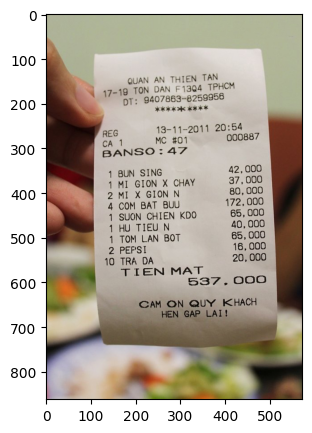

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: {'Tên quán': 'QUAN AN THIEN TAN', 'Địa chỉ': '17-19 TON DAN F13Q4 PHCM', 'Số điện thoại': '9407863-629956', 'Ngày giờ': '13-11-2011 20:54', 'Số hóa đơn': '000887', 'Mã sản phẩm': 'BANSO: 47', 'Danh sách món': [{'Tên món': 'Bún Sing', 'Đơn giá': '42.000', 'Số lượng': '1'}, {'Tên món': 'Mì Giòn X Chay', 'Đơn giá': '37.000', 'Số lượng': '1'}, {'Tên món': 'Ngon N', 'Đơn giá': '80.000', 'Số lượng': '1'}, {'Tên món': 'Cơm Bát Bửu', 'Đơn giá': '172.000', 'Số lượng': '1'}, {'Tên món': 'Sườn Chiên KDO', 'Đơn giá': '65.000', 'Số lượng': '1'}, {'Tên món': 'Hủ Tiêu N', 'Đơn giá': '40.000', 'Số lượng': '1'}, {'Tên món': 'Tôm Lăn Bột', 'Đơn giá': '65.000', 'Số lượng': '1'}, {'Tên món': 'Pepsi', 'Đơn giá': '16.000', 'Số lượng': '1'}, {'Tên món': 'Trà Da', 'Đơn giá': '20.000', 'Số lượng': '10'}], 'Tổng tiền': '537.000', 'Tiền mặt': '537.000'}


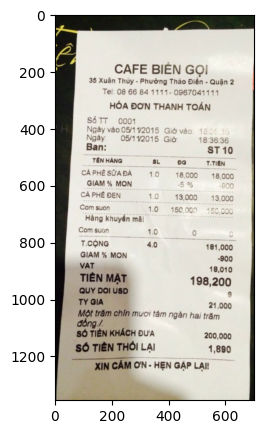

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: {'Tên quán': 'Cafe', 'Địa chỉ': '35 Xuân Thủy - Phường Thảo Điền - Quận 2', 'Số điện thoại': '08 66 84 1111 - 0967041111', 'Tên món': ['Cà phê đá', 'Cà phê đen', 'Cà phê sữa đá', 'Cơm đen', 'Cơm sườn'], 'Số lượng': [1, 1, 1, 1, 1], 'Đơn giá': [18.0, 18.0, 13.0, 1.0, 1.0], 'Thành tiền': [18.0, 18.0, 13.0, 150.0, 150.0], 'Tổng cộng': 181000, 'Giảm %': 0, 'VAT': 1900, 'Tiền mặt': 198200, 'Quy đổi USD': 21000, 'Tỷ giá': 9, 'Số tiền khách đưa': 200000, 'Số tiền thôi lại': 18900}


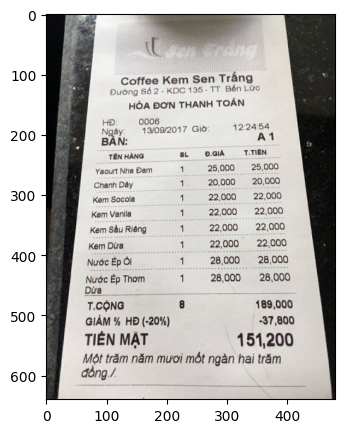

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: {'Tên quán': 'Coffee Kem Sen Trắng', 'Địa chỉ': 'Đường Số 2 - KDC 135 - TT Bến Lức', 'Số hóa đơn': '0006', 'Ngày': '13/09/2017', 'Giờ': '12:24:54', 'Bàn': 'A', 'Tên món': ['Yaourt Nha Đam', 'Chanh Dây', 'Kem Socola', 'Kem Vanilla', 'Kem Sầu Riêng', 'Kem Dừa', 'Nước Ép Ói', 'Nước Ép Thơm', 'Dứa'], 'Số lượng': [1, 1, 1, 1, 1, 1, 1, 1, 1], 'Đơn giá': [25000, 20000, 22000, 22000, 22000, 22000, 28000, 28000, 28000], 'Thành tiền': [25000, 20000, 22000, 22000, 22000, 22000, 28000, 28000, 28000]}


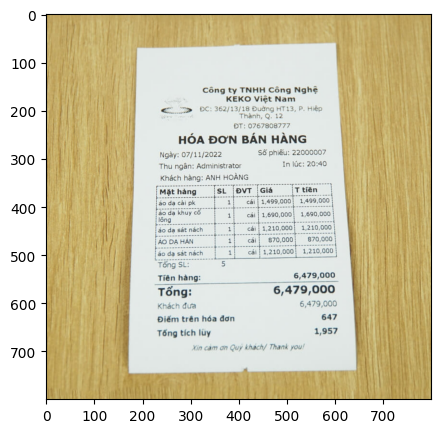

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: {'Tên công ty': 'Công ty TNHH Công Nghệ', 'Địa chỉ': '362/13 Đường Đuối Nam, P. Hiệp Thành, Q. 12, Thành phố Đà Nẵng', 'Số điện thoại': '0769087777', 'Ngày': '07/11/2022', 'Số phiếu': '22000007', 'Thu ngân': 'Administrator', 'Khách hàng': 'ANH HOÀNG', 'Mặt hàng': ['Áo dạ cải pk', 'Áo dạ khuy cổ', 'Áo dạ sát nách', 'AO DA HÂN', 'Áo dạ sát nách'], 'SL': ['1', '1', '1', '1', '1'], 'ĐVT': ['cái', 'cái', 'cái', 'cái', 'cái'], 'Giá': ['1,499,000', '1,690,000', '1,210,000', '870,000', '1,210,000'], 'Tính': ['1,499,000', '1,690,000', '1,210,000', '870,000', '1,210,000'], 'Tổng SL': '5', 'Tổng tiền hàng': '6,479,000', 'Tiền hàng': '6,479,000', 'Tổng': '6,479,000', 'Khách đưa': '64', 'Điểm trên hóa đơn': '1,957', 'Tổng tích lũy': '1,957'}


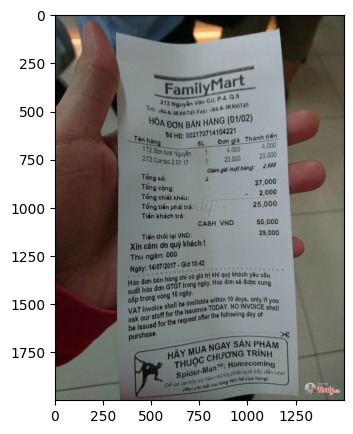

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
Trích xuất thông tin hoá đơn trong ảnh.
Assistant: {'Tên cửa hàng': 'FamilyMart', 'Địa chỉ': '213 Nguyễn Văn Cừ, P.4, Q.5', 'Số điện thoại': '028-38376974', 'Số hóa đơn': '0021701410421', 'Ngày tháng': '14/07/2017', 'Giờ': '10:42', 'Mã hoá đơn': '0021701410421', 'Tên sản phẩm 1': 'Bún tươi ngon', 'Số lượng 1': '1', 'Đơn giá 1': '23.000', 'Thành tiền 1': '23.000', 'Tổng số lượng': '2', 'Tổng cộng': '2.000', 'Tổng tiền phải trả': '25.000', 'Tiền khách trả': '50.000', 'Tiền thối lại': '25.000', 'Thông tin khác': 'Hãy mua ngay sản phẩm thuộc chương trình Spider-Man, Homme'}


In [ ]:
### Test samples
test_folder = '/content/test'
for filename in os.listdir(test_folder):
    image_path = os.path.join(test_folder, filename)
    image = Image.open(image_path).convert('RGB')

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.show()

    pixel_values = load_image(image_path, max_num=12).to(torch.bfloat16).cuda()
    generation_config = dict(max_new_tokens= 1024, do_sample=False, num_beams = 3, repetition_penalty=2.0)

    question = '<image>\nTrích xuất thông tin hoá đơn trong ảnh.'

    response = model.chat(tokenizer, pixel_values, question, generation_config)
    print(f'User: {question}\nAssistant: {response}')
    print("="*30)

This guide provided a step-by-step approach to enhancing the InternVL2 model on Viet-Receipt-VQA using LoRA fine-tuning. By following these instructions, you should be able to achieve improved performance in extraction tasks.  Viet-Receipt-VQA is just one example; you can replace it with other downstream datasets for fine-tuning. Happy fine-tuning!

DON'T WORRY ABOUT IT! WE HERE FOR YOU <3

You could find more Vietnamese datasets here.

Check it more about us: [Fifth Civil Defender - 5CD - AI](https://huggingface.co/5CD-AI)

